# Answers week 5

* Red text: session quiz question
* Cell with code open: needs to be checked by TA
* Missing numbers: coursework questions (3, 8, 


#### *Question 5.1*

In [13]:
from pathlib import Path
import os

file = "galaxyclusters.txt"
mode = 'w'                  
f = open(file, mode) 
f.write("Bullet Cluster\n")
f.write("Virgo Cluster\n")
f.write("El Gordo\n")
f.write("Coma Cluster\n")
f.write("Pandora's Cluster")
f.close()

root_path = os.path.expanduser('~')
subdirectory = 'PROGNUM-repo/Task5'
filename = 'galaxyclusters.txt'
OSpath = f"{root_path}/{subdirectory}/{filename}"
path = Path(OSpath)

mode2 = 'r'
f1 = open(path, mode2)

with open(path, mode2) as f1:
    count = 1
    for line in f1:
        s = line.rstrip('\n')
        print(f"Galaxy cluster {count} is {s}.")
        count += 1

Galaxy cluster 1 is Bullet Cluster.
Galaxy cluster 2 is Virgo Cluster.
Galaxy cluster 3 is El Gordo.
Galaxy cluster 4 is Coma Cluster.
Galaxy cluster 5 is Pandora's Cluster.


#### <span style="color:red"> *Question 5.2*

In [1]:
import numpy as np

name = input("Enter the name of your file:")

data = np.loadtxt(name)

x = data[:,0]  # Make array 'x' of the first column
y = data[:,1]  # Make array 'y' of the second column

min_x = np.min(x)
max_x = np.max(x)
mean_x = np.mean(x)

min_y = np.min(y)
max_y = np.max(y)
mean_y = np.mean(y)

print(f"x = {x}, with a minimum of {min_x}, a maximum of {max_x} and a mean of {mean_x}.")
print(f"y = {y}, with a minimum of {min_y}, a maximum of {max_y} and a mean of {mean_y}.")

y2 = (y-np.median(y))**2  # The question says median, so I assumed you have to calculate that with a NumPy function.
print(f"The contents of the new array y2 are: y2 = {y2}.")

Enter the name of your file: SQ5.2


FileNotFoundError: SQ5.2 not found.

#### *Question 5.4*

In [4]:
import numpy as np

A = np.zeros((5,4))

B = np.arange(6).reshape(3,2)+10

print(A)
print(B)

Middle = A[1:4,1:3]
np.copyto(Middle, B)

print(A)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[10 11]
 [12 13]
 [14 15]]
[[ 0.  0.  0.  0.]
 [ 0. 10. 11.  0.]
 [ 0. 12. 13.  0.]
 [ 0. 14. 15.  0.]
 [ 0.  0.  0.  0.]]


You copy the data from array B, then use slicing to input it into A.

#### *Question 5.5*

In [24]:
import numpy as np

M = np.arange(60).reshape(3,4,5)  # Amount of blocks, rows per block, columns per block.

print(M, f"\n")
print(M[1,2,3])  # To get number: block, row, column

[[[ 0  1  2  3  4]
  [ 5  6  7  8  9]
  [10 11 12 13 14]
  [15 16 17 18 19]]

 [[20 21 22 23 24]
  [25 26 27 28 29]
  [30 31 32 33 34]
  [35 36 37 38 39]]

 [[40 41 42 43 44]
  [45 46 47 48 49]
  [50 51 52 53 54]
  [55 56 57 58 59]]] 

33


#### <span style="color:red"> *Question 5.6*

In [29]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

np.concatenate((a, b))

array([1, 2, 3, 4, 5, 6])

The shape is an array containing a list.

In [119]:
import numpy as np

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

np.concatenate((a, b))  # Output: all 4 rows below each other
np.concatenate((a, b), axis=0)  # Output: all 4 rows below each other
#np.concatenate((a, b), axis=1)  # Output: first entry of both arrays on the first row, second entries on the second row

array([[1, 2],
       [3, 4],
       [5, 6],
       [7, 8]])

The arrays in question 1 have 1 row, 3 columns each, while the arrays in question 2 have 2 rows, with 2 columns each.

The axis = 0 specifies along the y-axis (as z is not present), so the rows are added to each other/
The axis = 1 specifies along the x-axis, so the columns are added, so the code concatenates the first columns (of both), then the second columns.

#### *Queston 5.7*

In [58]:
import numpy as np

a = np.arange(60, dtype=np.complex128)

a.nbytes  #960 

a = np.arange(60, dtype=np.int8)

a.nbytes  #60

60

#### <span style="color:red"> *Question 5.9*

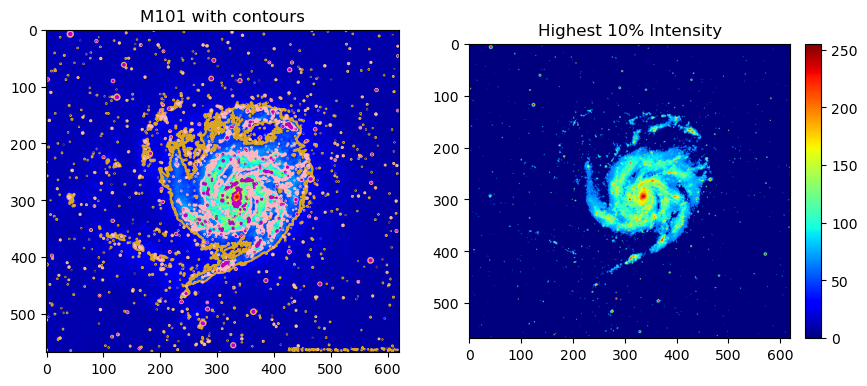

In [79]:
import numpy as np
import imageio.v2 as imio
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

M101 = imio.imread("~/PROGNUM-repo/Task5/m101BW.jpg")  # Get data from image as array

fig = plt.figure(figsize=(10,10))  # Set figure size
frame = fig.add_subplot(1,2,1)  # Frame inside figure
frame.imshow(M101, cmap='jet')  # Show image in colormap 'jet' inside the frame
frame.contour(M101, levels=np.percentile(M101, [85,95,99.7]), colors=['goldenrod','lightpink','m'])
plt.title("M101 with contours")

level = np.percentile(M101, 90)
filtered = np.where(M101 >= level, M101, 0)  # Filter data where it is above 90 percent intensity, then plot those from M101, other values will show as 0

frame2 = fig.add_subplot(1,2,2)  # Plot two
intensity = frame2.imshow(filtered, cmap='jet')
plt.title("Highest 10% Intensity")

# Scale the colorbar

divider = make_axes_locatable(frame2)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

fig.colorbar(intensity, cax=colbarframe)
plt.show()

#### <span style="color:red"> *Question 5.10*

The z-profile near/in the middle of the xy-plane is:
 [0.00482 0.00666 0.00705 0.00889 0.01269 0.02012 0.02789 0.03712 0.03985
 0.04617 0.0606  0.04935 0.02734 0.01746 0.0149  0.0247  0.03478 0.03472
 0.03174 0.02931 0.02995 0.02909 0.02687 0.0247  0.02483 0.02504 0.02486
 0.0228  0.01888 0.01625 0.01589 0.01473 0.01294 0.01236 0.01144 0.01118
 0.01038 0.00848 0.00751 0.0072 ]

The elementary statistics of the z-profile are:
 The maximum: 0.0606
 The minimum: 0.00482
 The sum: 0.89154
 The mean: 0.0222885
 The standard deviation: 0.012699434544498428.


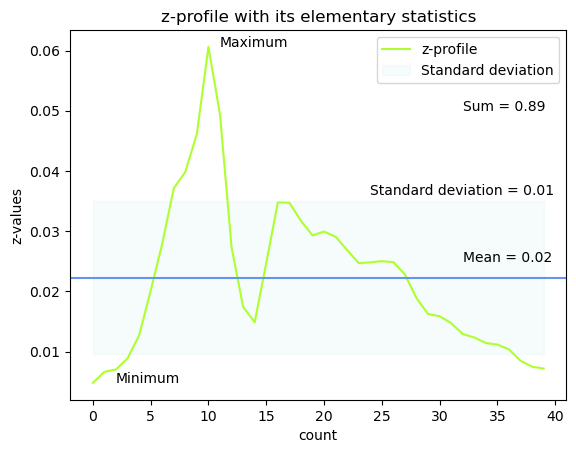

In [58]:
import numpy as np
from matplotlib import pyplot as plt

data = np.loadtxt("ngc6946.txt")  # Get data from txt file as array
data_shape = data.reshape(40, 50, 70)  # Reschape into (z, y, x) = (40, 50, 70)

z_profile = data_shape[:, 25, 35]  # Get data from middle of xy-plane
print(f"The z-profile near/in the middle of the xy-plane is:\n {z_profile}\n")

# Calculate the elementary statistics

z_max = np.max(z_profile)
z_min = np.min(z_profile)
z_sum = np.sum(z_profile)
z_mean = np.mean(z_profile)
z_stdev = np.std(z_profile)

print(f"The elementary statistics of the z-profile are:\n The maximum: {z_max}\n The minimum: {z_min}\n The sum: {z_sum}\n The mean: {z_mean}\n The standard deviation: {z_stdev}.")

# Create a plot

plt.plot(z_profile, color='greenyellow', label="z-profile")
plt.title("z-profile with its elementary statistics")
plt.xlabel("count")
plt.ylabel("z-values")

plt.axhline(z_mean, color='cornflowerblue')  # Plot mean line
plt.fill_between(range(len(z_profile)), z_mean-z_stdev, z_mean+z_stdev, color='powderblue', alpha=0.1, label="Standard deviation")  # Plot standard deviation

# Use text to enter statistics in plot

plt.text(11, z_max, "Maximum")
plt.text(2, z_min, "Minimum")
plt.text(32, 0.05, f"Sum = {z_sum:.2f}")
plt.text(32, 0.025, f"Mean = {z_mean:.2f}")
plt.text(24, 0.001+z_mean+z_stdev, f"Standard deviation = {z_stdev:.2f}")

plt.legend()
plt.show()

#### <span style="color:red"> *Question 5.11*

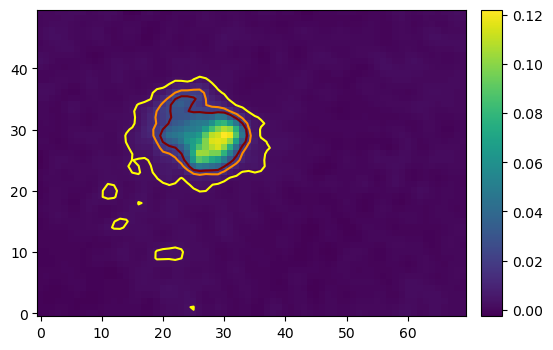

In [92]:
import numpy as np
from matplotlib import pyplot as plt
import imageio.v2 as imio
from mpl_toolkits.axes_grid1 import make_axes_locatable

data = np.loadtxt("ngc6946.txt")  # Get data from txt file as array
data_shape = data.reshape(40, 50, 70)  # Reschape into (z, y, x) = (40, 50, 70)

image = data_shape[0, :, :]  # Extract first plane for all x and y values

# Calculate mean and standard deviation

im_mean = np.mean(image)
im_stdev = np.std(image)

fig = plt.figure(figsize=(6,6))  # Set figure size
frame = fig.add_subplot(1,1,1)
plt.imshow(image, origin='lower')  # Plot image and lower axis

# Scale the colorbar to the figure

locate = make_axes_locatable(frame)
bar = locate.append_axes("right", size="5%", pad=0.15)
plt.colorbar(cax=bar)

frame.contour(image, levels=[im_mean, im_mean+im_stdev, im_mean+(2*im_stdev)], colors=['yellow','darkorange','maroon'])  # Add contour

plt.show()

#### <span style="color:red"> *Question 5.12*

In [1]:
from scipy.constants import c  # in m/s

class Galaxy:    
    """Class for redshift calculation of galaxies"""  
        
    caH_0 = 3968.5  # Calcium H line in rest frame
    c_km = c/1000  # Speed of light in km/s
    
    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH
        return z
    def velocity(self, z):
        v = self.c_km*z  # With self, you can use self-defined variables (variables defined in the class)
        return v

galaxy_1 = Galaxy("NGC1832", 3994.7)

print(f"The velocity of {galaxy_1.name} is: {galaxy_1.velocity(galaxy_1.redshift())} km/s")

The velocity of NGC1832 is: 1966.2458756852693 km/s


#### <span style="color:red"> *Question 5.13*

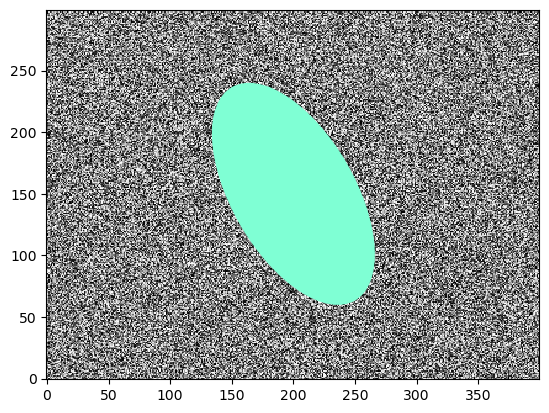

In [118]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse

class AstroEllipse(Ellipse):
   def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
      # We use the (sort of) astronomical angle where 'angle' defines)
      # the position angle of the major axis of a ring projected onto the sky
      # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
      # the north direction on the sky and the major axis of the receding half of the
      # galaxy (Rots 1975, astron, astrophys 45, 43).
      # Here we assume (!) north is in the positive Y direction.
      # If not, you need to correct the angle for the rotation of the image.
      # Parameter 'position_angle' enters in degrees
      assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
      XY = (xc, yc)                  # MPL requires center as a tuple
      angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
      height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
      width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
      super().__init__(XY, width, height, angle=angle_mpl, **args)

Nx = 400
Ny = 300
data = np.random.random((Ny,Nx))

ellipse = AstroEllipse(200, 150, 100, 50, 30, facecolor='aquamarine')  # Coordinates of x, y, semi_major, semi_minor, position-angle, **args can be any arguments, including any plot effects of the ellipse.

plt.imshow(data, interpolation='none', origin="lower", cmap='gray')
plt.gca().add_patch(ellipse)  # Get current axis is necessary to draw on the figure. You need to get the axis of the figure or create a new one in order to draw the ellipse on the figure.
                              # The add_patch function also needs an axis specified.
plt.show()